In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install ultralytics

In [8]:
import yaml

yaml_path = '/content/drive/MyDrive/ComputerVisionKidneyStone/dataset/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = '/content/drive/MyDrive/ComputerVisionKidneyStone/dataset/train/images'
data['val']   = '/content/drive/MyDrive/ComputerVisionKidneyStone/dataset/valid/images'
data['test']  = '/content/drive/MyDrive/ComputerVisionKidneyStone/dataset/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("Path တွေ ပြင်ပြီးပါပြီ။ အခု Train တာကို ပြန်စလို့ရပါပြီ!")

Path တွေ ပြင်ပြီးပါပြီ။ အခု Train တာကို ပြန်စလို့ရပါပြီ!


In [9]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/drive/MyDrive/ComputerVisionKidneyStone/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    plots=True
)

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ComputerVisionKidneyStone/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl


image 1/1 /content/kidney-stones-on-abdominal-ct-600nw-2579584785.jpg: 640x448 2 Tas_Vars, 290.9ms
Speed: 3.8ms preprocess, 290.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 448)
------------------------------
🔍 ရလဒ်အဖြေလွှာ
------------------------------
✅ တွေ့ရှိရသော ဆီးကျောက် အရေအတွက်: 2 ခု
⚠️ ရောဂါအခြေအနေ သုံးသပ်ချက်: သတိပြုရန် - ဆီးကျောက် အနည်းငယ် တွေ့ရှိရပါသည်။
------------------------------


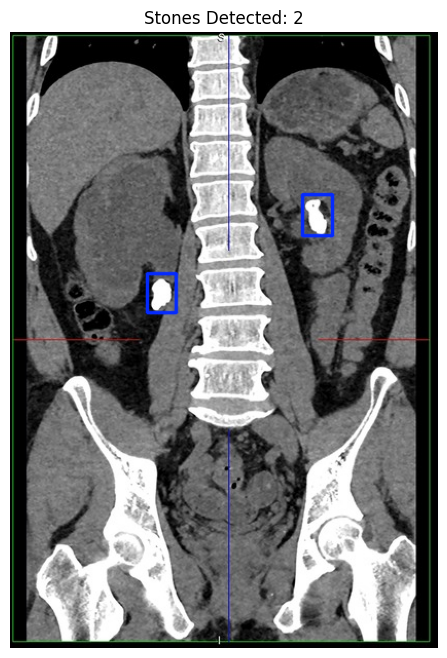

In [17]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# ၁။ Model ခေါ်မယ်
model = YOLO('/content/runs/detect/train11/weights/best.pt')

# ၂။ စမ်းသပ်မယ့်ပုံ
test_image = '/content/drive/MyDrive/ComputerVisionKidneyStone/dataset/test/images/1-3-46-670589-33-1-63703718086120120200001-5487554579919763006_png_jpg.rf.9fd67251e99a47dbe83a5db6efe6c016.jpg'

url="https://www.shutterstock.com/image-illustration/kidney-stones-on-abdominal-ct-600nw-2579584785.jpg"

results = model.predict(source=url, conf=0.25, save=False)

for r in results:
    # ကျောက်အရေအတွက်ကို တွက်မယ်
    stone_count = len(r.boxes)

    print("-" * 30)
    print(f"🔍 ရလဒ်အဖြေလွှာ")
    print("-" * 30)
    print(f"✅ တွေ့ရှိရသော ဆီးကျောက် အရေအတွက်: {stone_count} ခု")

    # ရောဂါအခြေအနေ သုံးသပ်ချက်
    if stone_count == 0:
        status = "ပုံမှန်ဖြစ်ပါသည်။ ဆီးကျောက် မတွေ့ရှိပါ။"
    elif 1 <= stone_count <= 2:
        status = "သတိပြုရန် - ဆီးကျောက် အနည်းငယ် တွေ့ရှိရပါသည်။"
    else:
        status = "သတိကြီးစွာ ထားရန် - ဆီးကျောက် အများအပြား တွေ့ရှိရပါသည်။"

    print(f"⚠️ ရောဂါအခြေအနေ သုံးသပ်ချက်: {status}")
    print("-" * 30)

    # ပုံကို ပြသခြင်း (Label ကို ဖျောက်ပြီး အကွက်ပဲ ပြမယ်)
    # labels=False က Tas_Var ဆိုတဲ့ စာသားကို ဖျောက်ပေးတာ
    # boxes=True ကတော့ အကွက်လေးကို ချန်ထားပေးတာ
    im_array = r.plot(labels=False, conf=False)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Stones Detected: {stone_count}")
    plt.show()